Name :- Mohini Deshmukh

Roll No. :- 76

PRN :- 2425010071

Course :- Deep Learning Laboratory

Class :- TY Data Science


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


In [ ]:
np.random.seed(42)

data = {
    'GRE Score': np.random.randint(290, 340, 400),
    'TOEFL Score': np.random.randint(92, 120, 400),
    'University Rating': np.random.randint(1, 6, 400),
    'SOP': np.round(np.random.uniform(1, 5, 400), 1),
    'LOR': np.round(np.random.uniform(1, 5, 400), 1),
    'CGPA': np.round(np.random.uniform(6.5, 9.9, 400), 2),
    'Research': np.random.randint(0, 2, 400),
    'Chance of Admit': np.round(np.random.uniform(0.3, 0.95, 400), 2)
}

data = pd.DataFrame(data)
data.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,328,113,4,2.3,2.7,8.41,0,0.36
1,318,107,3,2.6,4.8,9.76,0,0.46
2,304,98,1,3.1,2.7,7.10,1,0.31
3,332,101,1,4.7,3.6,8.85,1,0.60
4,297,114,1,2.4,2.6,7.18,1,0.50


In [ ]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   GRE Score          400 non-null    int64  
 1   TOEFL Score        400 non-null    int64  
 2   University Rating  400 non-null    int64  
 3   SOP                400 non-null    float64
 4   LOR                400 non-null    float64
 5   CGPA               400 non-null    float64
 6   Research           400 non-null    int64  
 7   Chance of Admit    400 non-null    float64
dtypes: float64(4), int64(4)
memory usage: 25.1 KB


In [ ]:
data.describe()


,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,314.857500,106.170000,2.980000,2.998250,2.985750,8.195100,0.515000,0.617175
std,14.321661,8.224366,1.449086,1.185342,1.154753,0.990021,0.500401,0.186760
min,290.000000,92.000000,1.000000,1.000000,1.000000,6.510000,0.000000,0.300000
25%,303.000000,99.000000,2.000000,1.900000,1.975000,7.335000,0.000000,0.480000
50%,316.000000,107.000000,3.000000,3.000000,3.000000,8.220000,1.000000,0.620000
75%,326.250000,113.000000,4.000000,4.000000,3.900000,9.072500,1.000000,0.770000
max,339.000000,119.000000,5.000000,5.000000,5.000000,9.890000,1.000000,0.950000


In [ ]:
data.isnull().sum()


,0
GRE Score,0
TOEFL Score,0
University Rating,0
SOP,0
LOR,0
CGPA,0
Research,0
Chance of Admit,0


In [ ]:
X = data[['GRE Score','TOEFL Score','University Rating',
          'SOP','LOR','CGPA','Research']]
y = data['Chance of Admit']


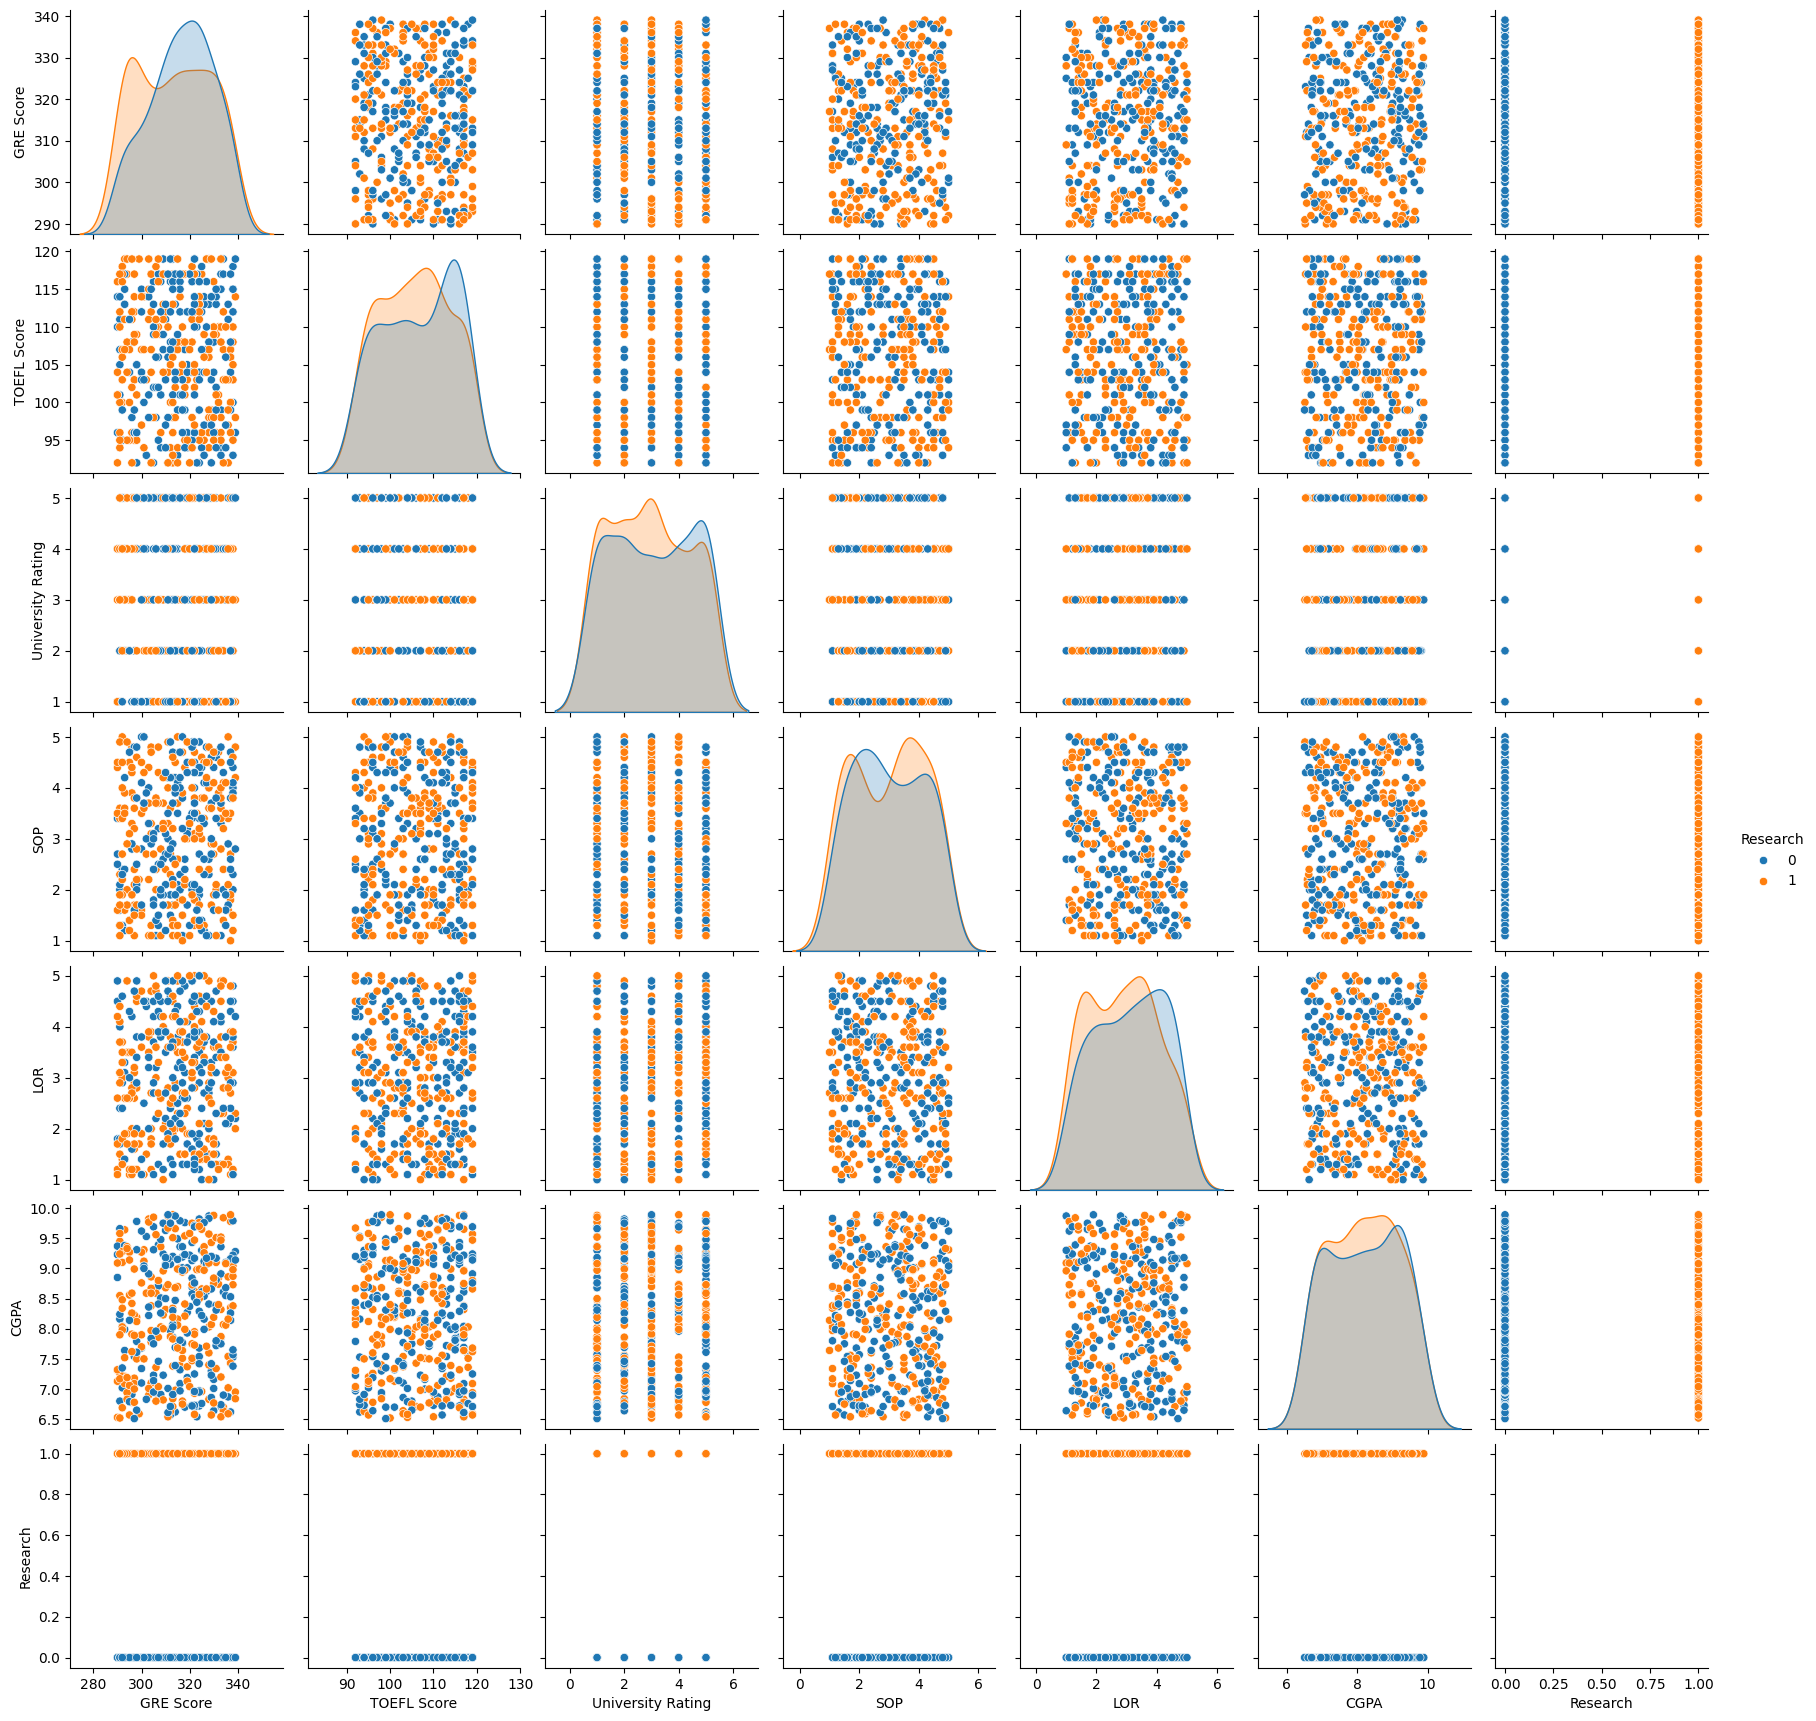

In [ ]:
sns.pairplot(data, vars=X.columns, hue='Research')
plt.show()

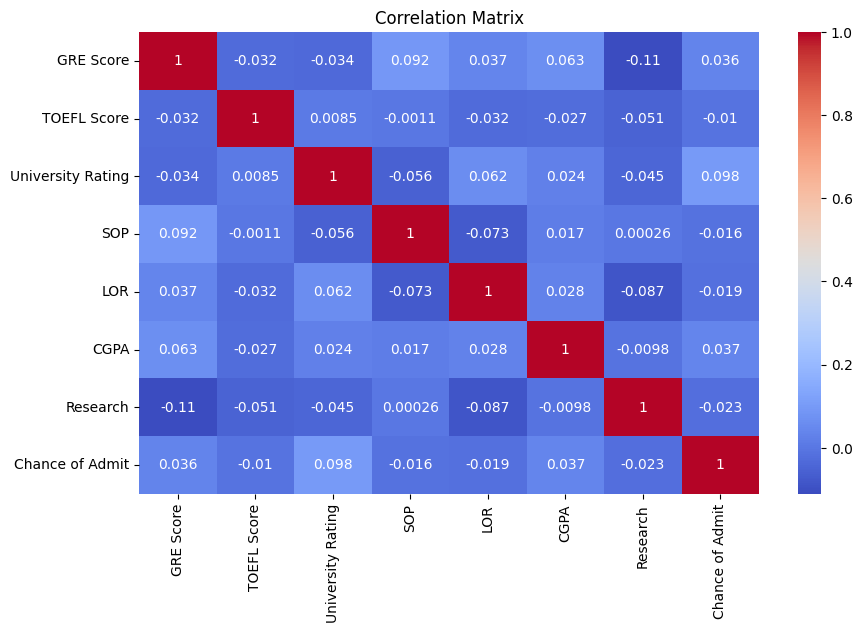

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


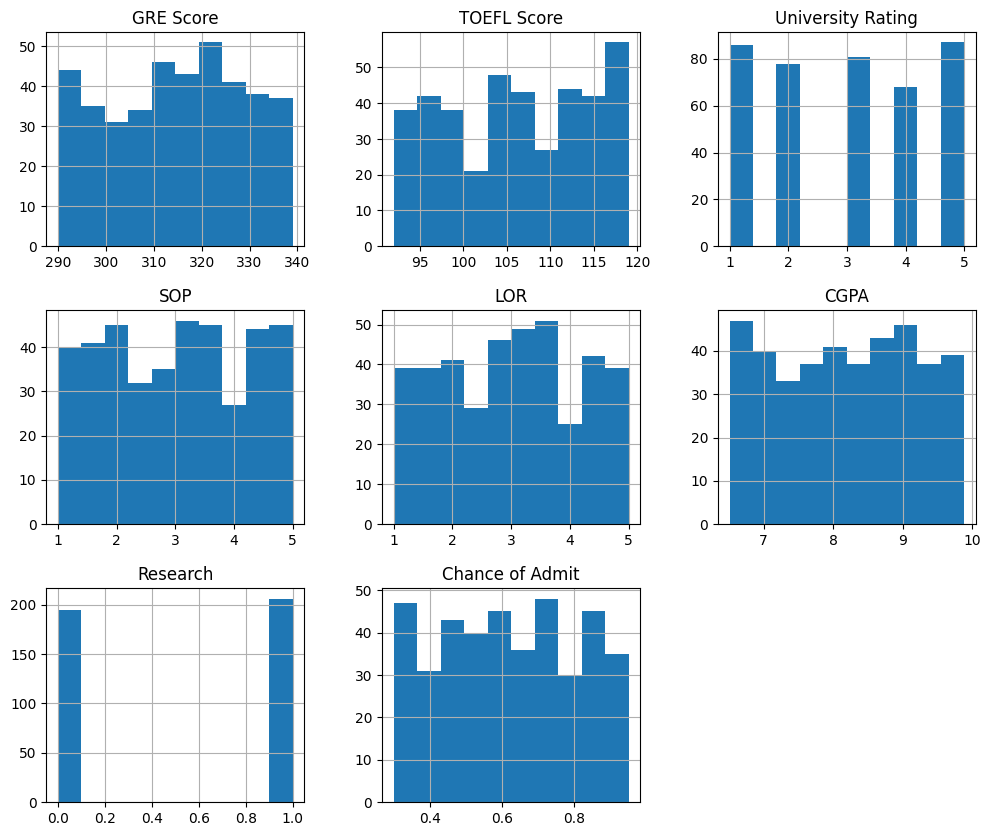

In [ ]:
data.hist(figsize=(12,10))
plt.show()


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
model = Sequential()
model.add(Dense(1, input_dim=7, activation='linear'))

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 93.3885 - val_loss: 25.3807
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 15.0557 - val_loss: 7.5554
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.3554 - val_loss: 8.3707
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.2148 - val_loss: 7.4942
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.9413 - val_loss: 7.4547
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2815 - val_loss: 7.4026
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.7948 - val_loss: 7.3600
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.2239 - val_loss: 7.3156
Epoch 9/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.1566 - val_loss: 7.2621
Epoch 10/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.0345 - val_loss: 7.2116
Epoch 11/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.1463 - val_loss: 7.1542
Epoch 12/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss:

In [ ]:
y_pred = model.predict(X_test)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


In [ ]:
r2_before = r2_score(y_test, y_pred)
print("R2 Score before scaling:", r2_before)


R2 Score before scaling: -40.50429256130009


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
model_scaled = Sequential()
model_scaled.add(Dense(1, input_dim=7, activation='linear'))

model_scaled.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

history_scaled = model_scaled.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    verbose=1
)


Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.8731 - val_loss: 2.0855
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.5910 - val_loss: 1.9873
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.5474 - val_loss: 1.8901
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.6735 - val_loss: 1.7949
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.5320 - val_loss: 1.7066
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.3621 - val_loss: 1.6234
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.4233 - val_loss: 1.5410
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.3409 - val_loss: 1.4636
Epoch 9/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.3076 - val_loss: 1.3882
Epoch 10/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.2001 - val_loss: 1.3172
Epoch 11/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.0139 - val_loss: 1.2505
Epoch 12/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.1264 - val_l

In [ ]:
y_pred_scaled = model_scaled.predict(X_test_scaled)
r2_after = r2_score(y_test, y_pred_scaled)

print("R2 Score after scaling:", r2_after)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
R2 Score after scaling: -0.05490503110714684


In [ ]:
predictions = model_scaled.predict(X_test_scaled)
predictions[:5]


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


array([[0.56085473],
       [0.58975035],
       [0.66074324],
       [0.629321  ],
       [0.644477  ]], dtype=float32)

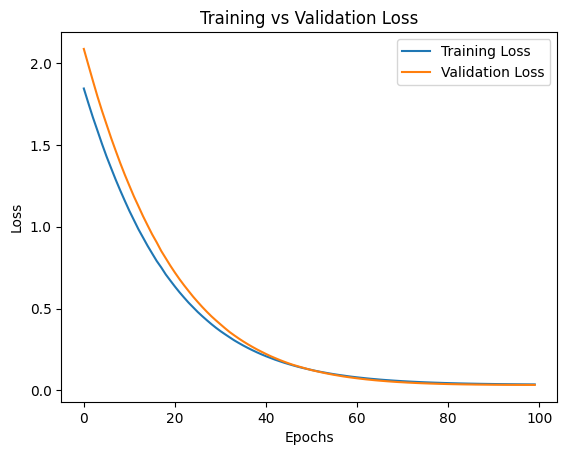

In [ ]:
plt.plot(history_scaled.history['loss'], label='Training Loss')
plt.plot(history_scaled.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()


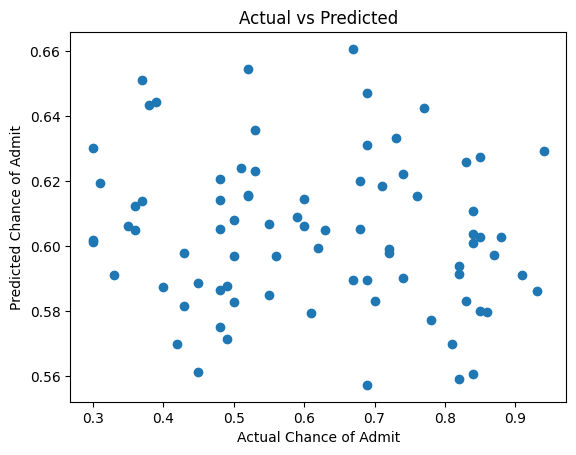

In [ ]:
plt.scatter(y_test, y_pred_scaled)
plt.xlabel("Actual Chance of Admit")
plt.ylabel("Predicted Chance of Admit")
plt.title("Actual vs Predicted")
plt.show()
